# Data Job Market: Skill Demand Analysis

**Goal:** What do employers actually ask for in Data Analyst vs Data Scientist job
postings? A text-mining pass over thousands of real postings to answer that with
numbers instead of anecdotes — doubles as market research for my own job search.

**Dataset:** [gsearch_jobs_2022](https://github.com/iweld/data-analyst-job-postings) —
5,488 real US data job postings pulled from Google Jobs search results
(Nov–Dec 2022), originally compiled by Luke Barousse. Each posting already has a
`description_tokens` field: a pre-extracted list of tools/technologies mentioned
in the job description (e.g. `excel`, `power_bi`, `python`, `sql`).

**Scope note:** this is a two-month US snapshot (Nov–Dec 2022), not a multi-year
trend line — framed here as a skill-demand snapshot, not a time series.

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# Validated categorical palette (see dataviz skill) — fixed slot order, not cycled
BLUE, AQUA, YELLOW, GREEN, VIOLET, RED, MAGENTA, ORANGE = (
    "#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"
)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.family"] = "sans-serif"
sns.set_theme(style="whitegrid")
CHART_DIR = "../assets"
os.makedirs(CHART_DIR, exist_ok=True)

## 1. Load & classify roles

In [2]:
df = pd.read_csv("../data/gsearch_jobs_2022.csv")
print(df.shape)
df[["title", "company_name", "search_term", "salary_standardized", "description_tokens"]].head(3)

(5488, 27)


,title,company_name,search_term,salary_standardized,description_tokens
0,"Manager, Strategic Research",Harnham US,data analyst,NaN,"['excel', 'spss']"
1,"Sr. Analyst, Operations Data",Virgin Galactic,data analyst,NaN,"['power_bi', 'excel']"
2,"Sr. Analyst, Operations Data",Virgin Galactic,data analyst,NaN,"['power_bi', 'excel']"


In [3]:
def classify_role(title: str) -> str:
    t = str(title).lower()
    is_scientist = "scientist" in t or "science" in t
    is_analyst = "analyst" in t
    if is_scientist and not is_analyst:
        return "Data Scientist"
    if is_analyst and not is_scientist:
        return "Data Analyst"
    if is_analyst and is_scientist:
        return "Hybrid / Other"
    return "Hybrid / Other"

df["role"] = df["title"].apply(classify_role)
role_counts = df["role"].value_counts()
role_counts

role
Data Analyst      4430
Hybrid / Other     897
Data Scientist     161
Name: count, dtype: int64

## 2. Skill extraction

`description_tokens` is a stringified Python list — parse it and explode into
one row per (posting, skill).

In [4]:
df["skills"] = df["description_tokens"].apply(lambda s: ast.literal_eval(s) if pd.notna(s) else [])
skills_long = df[["title", "role", "salary_standardized", "skills"]].explode("skills").dropna(subset=["skills"])
skills_long["skills"] = skills_long["skills"].str.replace("_", " ").str.title()
print(f"{skills_long['skills'].nunique()} distinct skills/tools mentioned across {df.shape[0]} postings")

113 distinct skills/tools mentioned across 5488 postings


## 3. Most in-demand skills overall

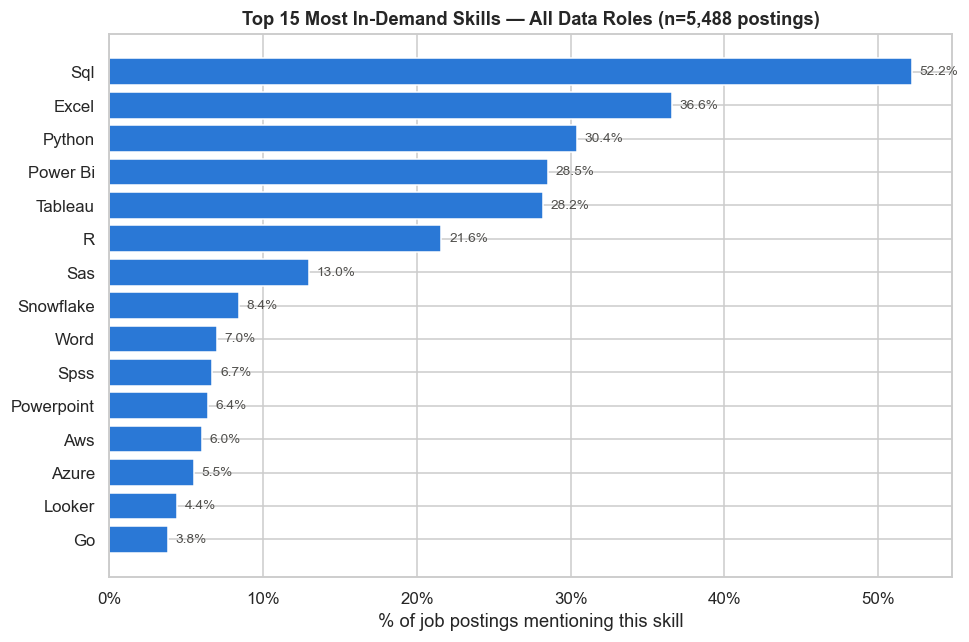

In [5]:
top_skills = skills_long["skills"].value_counts().head(15)
top_skills_pct = (top_skills / df.shape[0] * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top_skills_pct.index[::-1], top_skills_pct.values[::-1], color=BLUE)
ax.set_xlabel("% of job postings mentioning this skill")
ax.set_title("Top 15 Most In-Demand Skills — All Data Roles (n=5,488 postings)", fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
for bar, val in zip(bars, top_skills_pct.values[::-1]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2, f"{val}%", va="center", fontsize=9, color="#52514e")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/top_skills_overall.png", dpi=150)
plt.show()

## 4. Data Analyst vs Data Scientist: different toolkits

Restricting to the two clean role categories (excluding the ambiguous "Hybrid / Other" bucket):

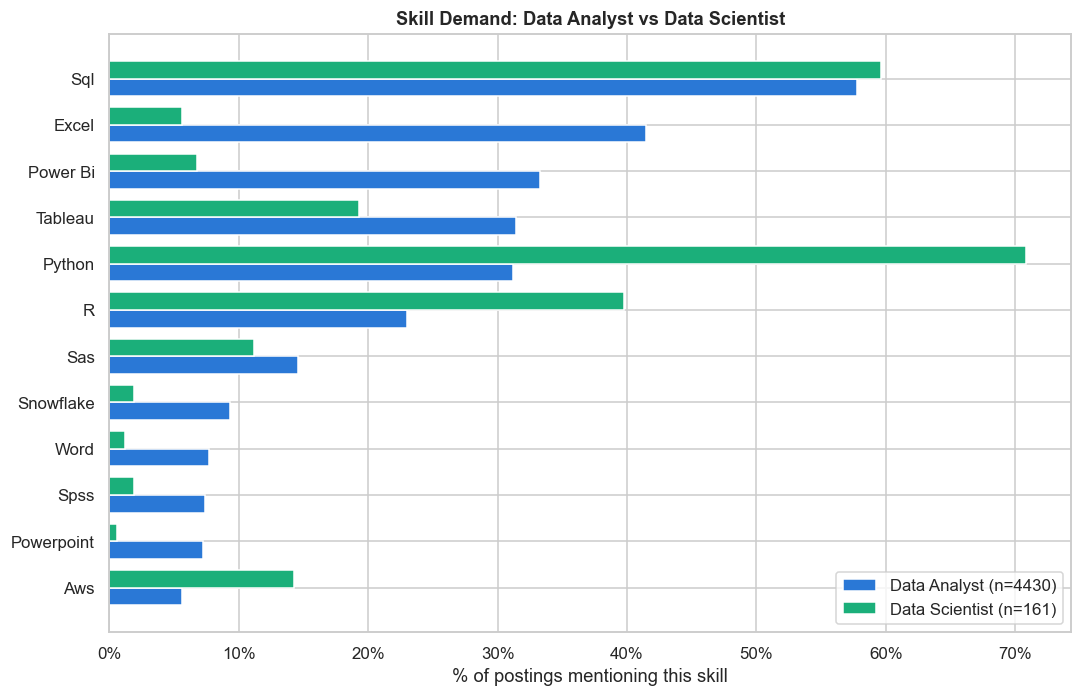

In [6]:
role_skills = skills_long[skills_long["role"].isin(["Data Analyst", "Data Scientist"])]
role_totals = df[df["role"].isin(["Data Analyst", "Data Scientist"])]["role"].value_counts()

pct_by_role = (
    role_skills.groupby(["skills", "role"]).size().unstack(fill_value=0)
    .div(role_totals, axis=1) * 100
)
top_combined = skills_long[skills_long["role"].isin(["Data Analyst", "Data Scientist"])]["skills"].value_counts().head(12).index
compare = pct_by_role.loc[top_combined].round(1).sort_values("Data Analyst")

fig, ax = plt.subplots(figsize=(10, 6.5))
y = np.arange(len(compare))
h = 0.38
ax.barh(y - h/2, compare["Data Analyst"], height=h, color=BLUE, label=f"Data Analyst (n={role_totals['Data Analyst']})")
ax.barh(y + h/2, compare["Data Scientist"], height=h, color=AQUA, label=f"Data Scientist (n={role_totals['Data Scientist']})")
ax.set_yticks(y)
ax.set_yticklabels(compare.index)
ax.set_xlabel("% of postings mentioning this skill")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title("Skill Demand: Data Analyst vs Data Scientist", fontsize=12, fontweight="bold")
ax.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/skills_by_role.png", dpi=150)
plt.show()

SQL and Excel dominate Analyst postings; Python and machine-learning-adjacent tools
(and a step up in stats) separate Scientist postings from Analyst ones — the two
roles clearly want different core toolkits even though both sit under "data."

## 5. Skills and salary

Only a subset of postings include a standardized salary figure — restricting to those:

987 postings (18.0%) have a standardized salary


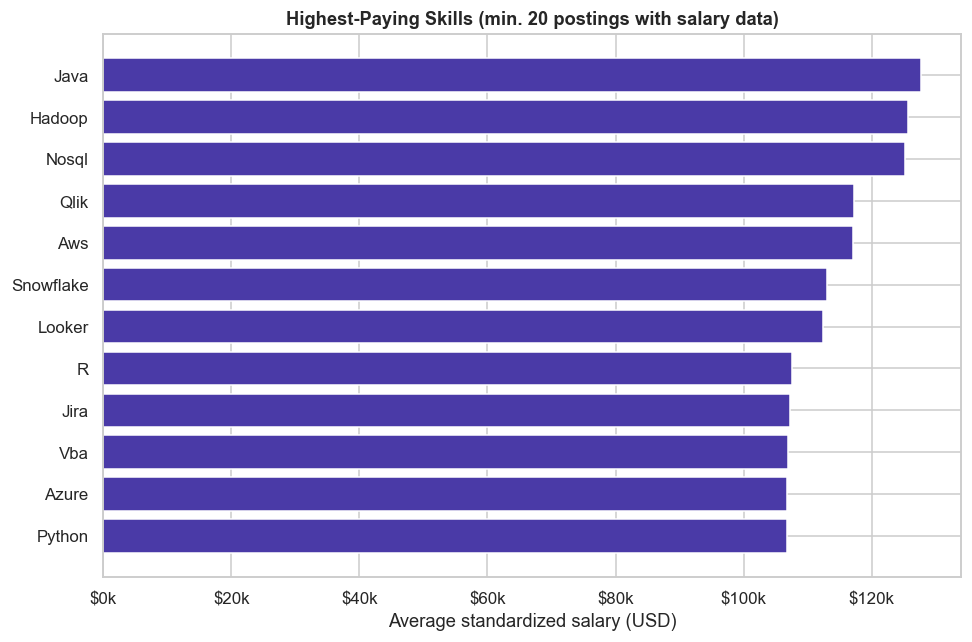

In [7]:
salary_df = df.dropna(subset=["salary_standardized"])
print(f"{salary_df.shape[0]} postings ({salary_df.shape[0]/df.shape[0]:.1%}) have a standardized salary")

salary_long = salary_df[["salary_standardized", "skills"]].explode("skills").dropna(subset=["skills"])
salary_long["skills"] = salary_long["skills"].str.replace("_", " ").str.title()

skill_salary = (
    salary_long.groupby("skills")
    .agg(avg_salary=("salary_standardized", "mean"), n=("salary_standardized", "size"))
    .query("n >= 20")
    .sort_values("avg_salary", ascending=False)
    .head(12)
    .round(0)
)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(skill_salary.index[::-1], skill_salary["avg_salary"][::-1], color=VIOLET)
ax.set_xlabel("Average standardized salary (USD)")
ax.set_title("Highest-Paying Skills (min. 20 postings with salary data)", fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/skills_salary.png", dpi=150)
plt.show()

## 6. Takeaways for my own job search

- **SQL and Excel are table stakes** for Data Analyst roles — near-universal across
  postings, worth having rock-solid rather than just "familiar with."
- **Python + statistics/ML tooling is the clear DA → DS differentiator** — the
  projects in this portfolio deliberately cover both sides of that line.
- Cloud/warehouse tools (e.g. AWS, Azure, Snowflake) and BI tools (Tableau, Power BI)
  show up often enough to be worth a passing familiarity even outside their "home" role.
- Skills tied to higher average posted salary skew toward specialized/production tooling
  rather than general-purpose spreadsheet tools — a signal for what to build depth in
  after landing the first role, not necessarily what to lead with in an entry-level search.